<a href="https://colab.research.google.com/github/AtharvRai67/task-6/blob/main/taskk10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Day 1: Explore & Understand the Data

In [5]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("customer_churn (3).csv")

print(df.head())
print(df.info())
print(df.describe())

# Check missing values
print(df.isnull().sum())

# Churn distribution
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True)*100)

# Drop unnecessary column
df.drop('CustomerID', axis=1, inplace=True)

Saving customer_churn (3).csv to customer_churn (3) (1).csv
  CustomerID  Tenure  MonthlyCharges  TotalCharges        Contract  \
0     C00001       6              64          1540        One year   
1     C00002      21             113          1753  Month-to-month   
2     C00003      27              31          1455        Two year   
3     C00004      53              29          7150  Month-to-month   
4     C00005      16             185          1023        One year   

      PaymentMethod PaperlessBilling  SeniorCitizen  Churn  
0       Credit Card               No              1      0  
1  Electronic Check              Yes              1      0  
2       Credit Card               No              1      0  
3  Electronic Check               No              1      0  
4  Electronic Check               No              1      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---

Day 2: Handle Categorical Data

In [6]:
#Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])

In [7]:
#One-Hot Encoding
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod'], drop_first=True)

In [8]:
df['SeniorCitizen'] = df['SeniorCitizen'].astype(int)

Day 3: Feature Scaling

In [9]:
#Standard Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['MonthlyCharges', 'TotalCharges', 'Tenure']] = scaler.fit_transform(
    df[['MonthlyCharges', 'TotalCharges', 'Tenure']]
)

In [10]:
#Min-Max Scaling (Alternative version)
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
df[['MonthlyCharges', 'TotalCharges', 'Tenure']] = minmax.fit_transform(
    df[['MonthlyCharges', 'TotalCharges', 'Tenure']]
)

In [13]:
#Compare Effects

#1. Statistical Comparison


# Define num_cols as it was not defined previously
num_cols = ['MonthlyCharges', 'TotalCharges', 'Tenure']

# At this point, 'df' contains the Min-Max scaled values because
# the Min-Max scaling cell was executed after the Standard scaling cell,
# and both modified 'df' in-place.

print("Current DataFrame (Min-Max Scaled):\n", df[num_cols].describe())

# The variables 'df_minmax' and 'df_standard' were not explicitly created
# as separate DataFrames in the preceding cells. To perform a direct comparison
# between original, standard-scaled, and min-max-scaled data, you would typically
# make copies of the DataFrame before applying each scaler (e.g., df_original_copy = df.copy()).
# As it stands in the current execution flow, 'df' is the min-max scaled version.

Current DataFrame (Min-Max Scaled):
        MonthlyCharges  TotalCharges      Tenure
count      500.000000    500.000000  500.000000
mean         0.523106      0.520730    0.507600
std          0.289385      0.288602    0.295244
min          0.000000      0.000000    0.000000
25%          0.262570      0.265320    0.257143
50%          0.530726      0.513660    0.514286
75%          0.770950      0.779746    0.757143
max          1.000000      1.000000    1.000000


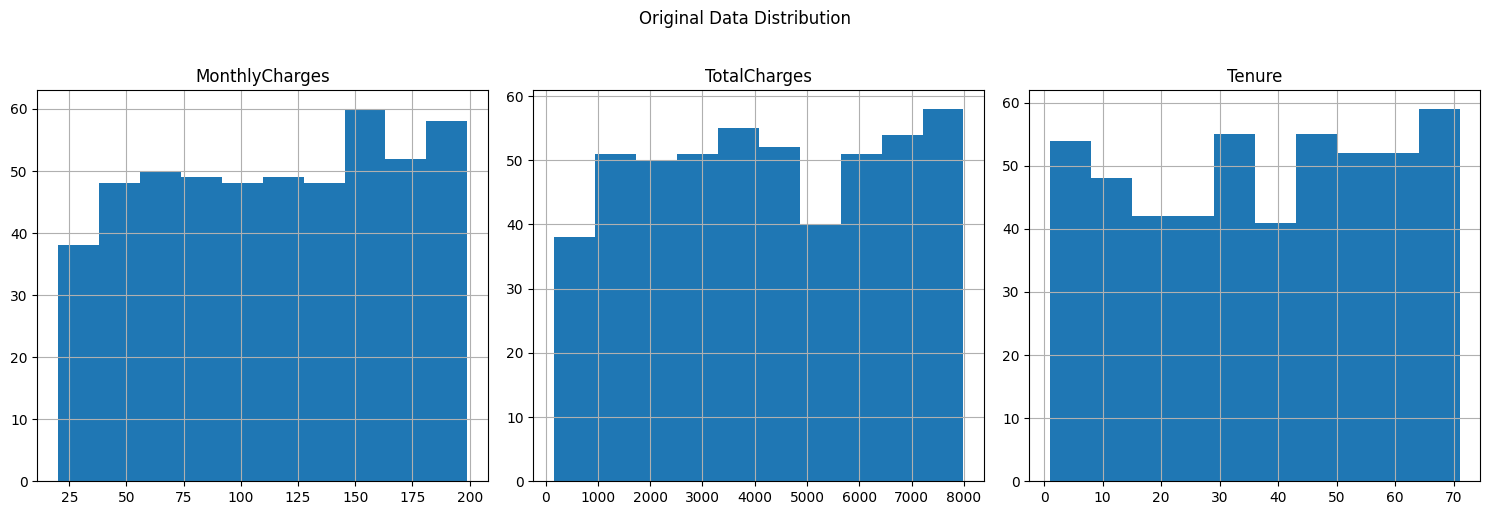

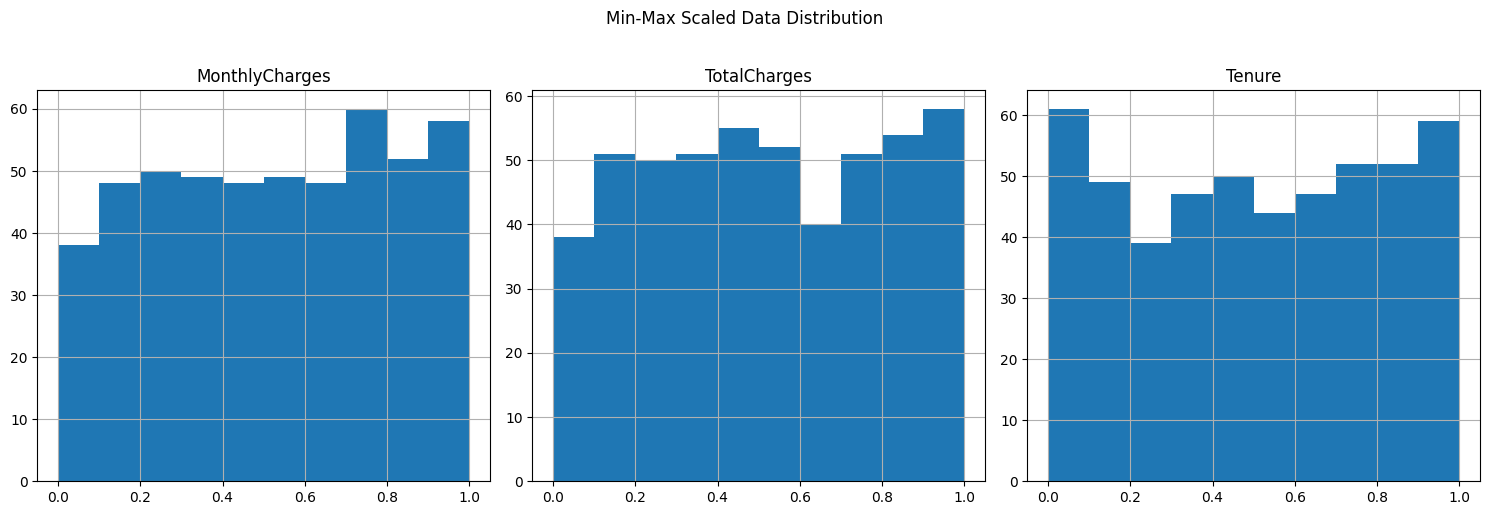

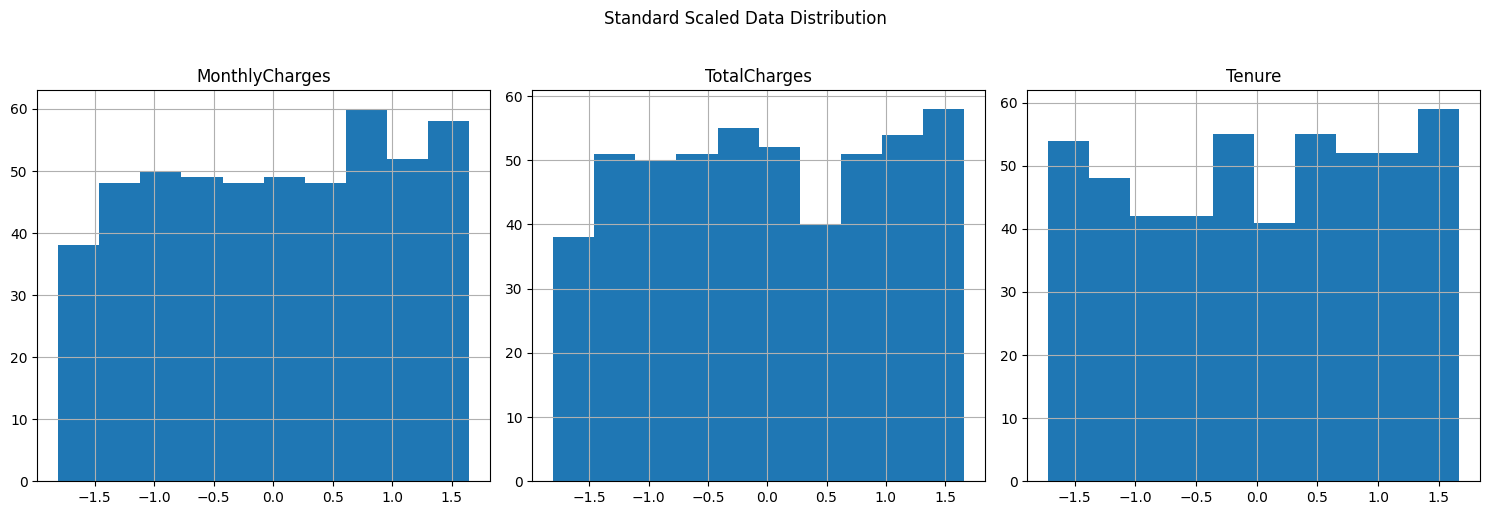

In [16]:
#2. Visualization Comparison
import matplotlib.pyplot as plt
import pandas as pd
from io import BytesIO
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# Re-load the original data to get the pre-scaled state for comparison
# Assuming 'uploaded' dictionary still holds the uploaded file content.
# We'll use the first key from the 'uploaded' dictionary, which should be our CSV file.
file_name = list(uploaded.keys())[0]
df_for_plotting = pd.read_csv(BytesIO(uploaded[file_name]))

# Apply preprocessing steps to 'df_for_plotting' to get it ready for scaling, but without scaling yet.
# These steps are copied from previous successful cells (7-p8stiBG7s9, keSKZCInHXNw, 3cdv2amUHjFH, l8HQp8j9HtBe)
df_for_plotting.drop('CustomerID', axis=1, inplace=True)

# Instantiate LabelEncoder outside the loop if used in multiple places, or inside if scope is limited
le = LabelEncoder()
df_for_plotting['PaperlessBilling'] = le.fit_transform(df_for_plotting['PaperlessBilling'])

df_for_plotting = pd.get_dummies(df_for_plotting, columns=['Contract', 'PaymentMethod'], drop_first=True)
df_for_plotting['SeniorCitizen'] = df_for_plotting['SeniorCitizen'].astype(int)

# Define numerical columns (should be consistent with previous cells)
num_cols = ['MonthlyCharges', 'TotalCharges', 'Tenure']

# Get the original (pre-scaled) numerical data for plotting
df_original_numeric = df_for_plotting[num_cols].copy()

# Apply Standard Scaling
scaler = StandardScaler()
df_standard_scaled_numeric = pd.DataFrame(scaler.fit_transform(df_for_plotting[num_cols]), columns=num_cols)

# Apply Min-Max Scaling
minmax = MinMaxScaler()
df_minmax_scaled_numeric = pd.DataFrame(minmax.fit_transform(df_for_plotting[num_cols]), columns=num_cols)


# Histogram comparison
# Plot Original Data
fig_original, axes_original = plt.subplots(ncols=len(num_cols), figsize=(15, 5))
df_original_numeric.hist(ax=axes_original)
fig_original.suptitle("Original Data Distribution", y=1.02)
plt.tight_layout()
plt.show()

# Plot Min-Max Scaled Data
fig_minmax, axes_minmax = plt.subplots(ncols=len(num_cols), figsize=(15, 5))
df_minmax_scaled_numeric.hist(ax=axes_minmax)
fig_minmax.suptitle("Min-Max Scaled Data Distribution", y=1.02)
plt.tight_layout()
plt.show()

# Plot Standard Scaled Data
fig_standard, axes_standard = plt.subplots(ncols=len(num_cols), figsize=(15, 5))
df_standard_scaled_numeric.hist(ax=axes_standard)
fig_standard.suptitle("Standard Scaled Data Distribution", y=1.02)
plt.tight_layout()
plt.show()

Key Difference

| Feature      | Min-Max Scaling | Standard Scaling |
| ------------ | --------------- | ---------------- |
| Range        | 0 to 1          | No fixed range   |
| Mean         | Changes         | Becomes 0        |
| Std Dev      | Changes         | Becomes 1        |
| Outliers     | Sensitive ❌     | Handles better ✅ |
| Distribution | Preserved       | Centered         |


Day 4: Outlier Detection & Handling

In [17]:
#IQR Method
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['MonthlyCharges'] >= Q1 - 1.5*IQR) &
        (df['MonthlyCharges'] <= Q3 + 1.5*IQR)]

In [18]:
#Z-Score Method
from scipy.stats import zscore

df = df[(zscore(df[['MonthlyCharges']]) < 3).all(axis=1)]

Day 5: Feature Engineering

In [19]:
# 1 Avg monthly spend
df['AvgCharges'] = df['TotalCharges'] / (df['Tenure'] + 1)

# 2 Tenure group
df['TenureGroup'] = df['Tenure'].apply(lambda x: 0 if x < 12 else 1)

# 3 High spender flag
df['HighSpender'] = (df['MonthlyCharges'] > df['MonthlyCharges'].mean()).astype(int)

# 4 Charges per tenure ratio
df['ChargeRatio'] = df['MonthlyCharges'] / (df['Tenure'] + 1)

# 5 Engagement score
df['EngagementScore'] = df['Tenure'] * df['MonthlyCharges']

Day 6: Feature Selection

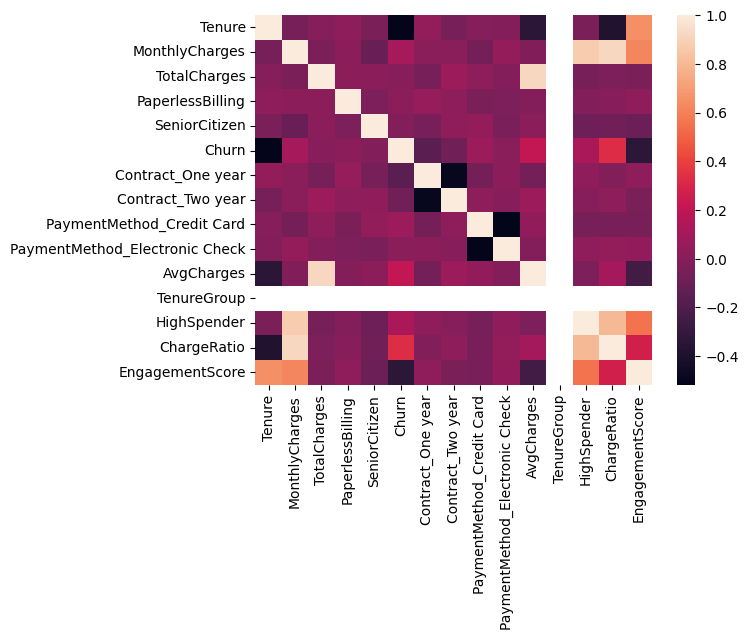

In [20]:
#Correlation Check
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.show()

In [21]:
#Remove low-impact features
df = df.drop(columns=['TenureGroup'])  # example

Day 7: Build Pipeline

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

X = df.drop('Churn', axis=1)
y = df['Churn']

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier())
])

pipeline.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestClassifier())])